# Bimodal Attention Network
1. Arousal-Valence Directed Data Augmentation
2. Multi-Head Attention Fusion
3. Regularisation via Sentiment Masking

* This experiment is conducted to test which technique apply to this enhanced framework is the most effective in contributing the improvement of metrics, compared to hybrid CNN-LSTM architecture.

# Setup and Configuration

In [13]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tf_keras import callbacks
from sklearn.metrics import classification_report, accuracy_score

# Import advanced functions
from ban_functions import (
    Config, 
    prepare_datasets, 
    prep_inputs, 
    build_attention_model, 
    run_evaluation
)

# 1. SETUP & CONFIGURATION
TARGET_CLASSES = ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust']
EPOCHS = 30 # Reduced slightly for faster ablation loops, adjust if needed
BATCH_SIZE = Config.BATCH_SIZE

# Dictionary to store results
ablation_results = {}

# Early stopping callback
early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=8, 
    restore_best_weights=True,
    verbose=1
)

# Helper function to train and evaluate a specific configuration
def run_ablation_experiment(name, use_aug, use_mask, use_attention):
    print(f"\n{'='*60}")
    print(f"EXPERIMENT: {name}")
    print(f" - Augmentation: {use_aug}")
    print(f" - Sentiment Masking: {use_mask}")
    print(f" - Attention Fusion: {use_attention}")
    print(f"{'='*60}")

    # Step A: Data Preparation (Handles Augmentation & Masking)
    original_mask_rate = Config.SENTIMENT_MASK_RATE
    Config.SENTIMENT_MASK_RATE = 0.60 if use_mask else 0.0
    
    data = prepare_datasets(TARGET_CLASSES, augment=use_aug)
    
    Config.SENTIMENT_MASK_RATE = original_mask_rate

    X_train = prep_inputs(data['X_m_train'], data['X_s_train'], data['sent_train_enc'])
    X_dev = prep_inputs(data['X_m_dev'], data['X_s_dev'], data['sent_dev_enc'])
    X_test = prep_inputs(data['X_m_test'], data['X_s_test'], data['sent_test_enc'])
    
    y_train = data['y_train']
    y_dev = data['y_dev']
    y_test = data['y_test']
    
    input_shapes = {
        'MFCC': (Config.MAX_MFCC_LEN, Config.N_MFCC),
        'Stats_Dim': 21 
    }

    # Step B: Model Building
    if use_attention:
        model = build_attention_model(input_shapes, len(TARGET_CLASSES), data['num_sent_classes'])
    else:
        model = build_simple_concat_model(input_shapes, len(TARGET_CLASSES), data['num_sent_classes'])

    # Step C: Training
    print("Training...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_dev, y_dev),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1
    )

    # Step D: Evaluation
    print("\n--- Evaluating ---")
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1) # Changed to 1 to show eval progress
    
    print("\nGenerating Predictions...")
    pred_probs = model.predict(X_test, verbose=1) # Changed to 1 to show predict progress
    preds = np.argmax(pred_probs, axis=1)
    
    # Generate full classification report
    class_names = data['le_target'].classes_
    
    # Print the full classification report to the console
    print(f"\n--- Full Classification Report for {name} ---")
    print(classification_report(y_test, preds, target_names=class_names, digits=4))
    
    # Get the dictionary version for storing in the results table
    report_dict = classification_report(y_test, preds, target_names=class_names, output_dict=True, digits=4)
    
    # Flatten the report dictionary for easy DataFrame construction
    metrics = {}
    metrics['Accuracy'] = report_dict['accuracy']
    metrics['Macro Precision'] = report_dict['macro avg']['precision']
    metrics['Macro Recall'] = report_dict['macro avg']['recall']
    metrics['Macro F1'] = report_dict['macro avg']['f1-score']
    
    # Add class-specific F1 scores
    for c in class_names:
        metrics[f'{c.capitalize()} F1'] = report_dict[c]['f1-score']
        metrics[f'{c.capitalize()} Precision'] = report_dict[c]['precision']
        metrics[f'{c.capitalize()} Recall'] = report_dict[c]['recall']

    return metrics

# --- Helper function for the "No Attention" baseline ---
def build_simple_concat_model(input_shapes, num_classes, num_sent_classes):
    from tf_keras import layers, models, optimizers, regularizers
    in_mfcc = layers.Input(shape=input_shapes['MFCC'])
    in_stats = layers.Input(shape=(input_shapes['Stats_Dim'],))
    in_sent = layers.Input(shape=(1,)) 

    # Audio Branch
    x_aud = layers.Conv1D(64, 3, padding='same', activation='relu')(in_mfcc)
    x_aud = layers.BatchNormalization()(x_aud)
    x_aud = layers.MaxPooling1D(2)(x_aud)
    x_aud = layers.LSTM(64, return_sequences=False)(x_aud)
    
    # Merge Audio + Stats
    x_stats = layers.Dense(32, activation='relu')(in_stats)
    x_audio_final = layers.Concatenate()([x_aud, x_stats])
    x_audio_proj = layers.Dense(64, activation='tanh')(x_audio_final)

    # Text Branch
    x_text = layers.Embedding(input_dim=num_sent_classes, output_dim=64)(in_sent)
    x_text = layers.Flatten()(x_text)
    x_text_proj = layers.Dense(64, activation='tanh')(x_text)

    # Simple Concatenation (NO ATTENTION)
    x_fused = layers.Concatenate()([x_audio_proj, x_text_proj])
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x_fused)
    x = layers.Dropout(Config.DROPOUT)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=[in_mfcc, in_stats, in_sent], outputs=outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=Config.LEARNING_RATE), 
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

## Experiment I: BAN (Baseline)

In [15]:
# ==========================================
# 2. RUN THE EXPERIMENTS
# ==========================================

# Exp 1: The Full Enhanced Framework (Everything ON)
ablation_results['Full BAN (All Enhancements)'] = run_ablation_experiment(
    "Full BAN", use_aug=True, use_mask=True, use_attention=True
)


EXPERIMENT: Full BAN
 - Augmentation: True
 - Sentiment Masking: True
 - Attention Fusion: True

--- Preparing Datasets (Classes: ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust']) ---

--- Processing Training Set ---
 -> Class 'neutral': 4709 original. Downsampling to 1700.


Processing neutral: 100%|██████████| 1700/1700 [01:07<00:00, 25.10it/s]


 -> Class 'joy': 1743 original. Downsampling to 1700.


Processing joy: 100%|██████████| 1700/1700 [01:22<00:00, 20.60it/s]


 -> Class 'sadness': 683 original. Expanding 3x to reach ~1700.


...


--- Processing dev Set (Original Only) ---


Processing disgust: 100%|██████████| 22/22 [00:00<00:00, 32.78it/s]



--- Processing test Set (Original Only) ---


Processing disgust: 100%|██████████| 68/68 [00:01<00:00, 38.56it/s]


Training...
Epoch 1/30
358/358 [==============================] - 25s 37ms/step - loss: 1.5173 - accuracy: 0.3887 - val_loss: 0.6056 - val_accuracy: 0.7839
Epoch 2/30
358/358 [==============================] - 13s 37ms/step - loss: 1.3080 - accuracy: 0.4547 - val_loss: 0.5390 - val_accuracy: 0.8246
Epoch 3/30
358/358 [==============================] - 13s 37ms/step - loss: 1.2227 - accuracy: 0.4886 - val_loss: 0.4961 - val_accuracy: 0.8340
Epoch 4/30
358/358 [==============================] - 15s 43ms/step - loss: 1.1729 - accuracy: 0.5118 - val_loss: 0.6207 - val_accuracy: 0.7923
Epoch 5/30
358/358 [==============================] - 15s 43ms/step - loss: 1.1161 - accuracy: 0.5420 - val_loss: 0.5094 - val_accuracy: 0.8027
Epoch 6/30
358/358 [==============================] - 15s 41ms/step - loss: 1.0487 - accuracy: 0.5712 - val_loss: 0.5374 - val_accuracy: 0.8267
Epoch 7/30
358/358 [==============================] - 14s 38ms/step - loss: 0.9916 - accuracy: 0.6003 - val_loss: 0.5920 - v

## Class Distribution after Augmentation

Extracting features and applying Arousal-Valence augmentation...

--- Preparing Datasets (Classes: ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust']) ---

--- Processing Training Set ---
 -> Class 'neutral': 4709 original. Downsampling to 1700.


Processing neutral: 100%|██████████| 1700/1700 [00:57<00:00, 29.48it/s]


 -> Class 'joy': 1743 original. Downsampling to 1700.


Processing joy: 100%|██████████| 1700/1700 [01:08<00:00, 24.98it/s]


 -> Class 'sadness': 683 original. Expanding 3x to reach ~1700.


...

Processing disgust: 100%|██████████| 271/271 [02:03<00:00,  2.19it/s]



--- Processing dev Set (Original Only) ---


Processing disgust: 100%|██████████| 22/22 [00:00<00:00, 23.23it/s]



--- Processing test Set (Original Only) ---


Processing disgust: 100%|██████████| 68/68 [00:03<00:00, 21.98it/s]
C:\Users\User\AppData\Local\Temp\ipykernel_22476\2681122537.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


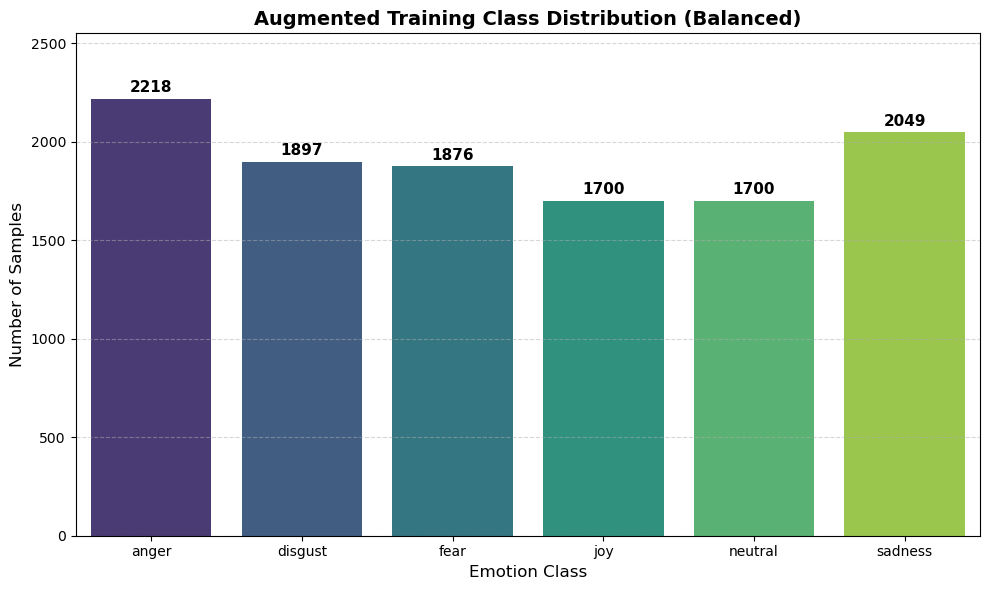

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from ban_functions import prepare_datasets, Config

# 1. Setup and Load Augmented Data
# Using the specific target classes for your research paper
TARGET_CLASSES = ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust']
print("Extracting features and applying Arousal-Valence augmentation...")
# This call handles the smart balancing (downsampling Neutral, augmenting minority classes)
data_check = prepare_datasets(TARGET_CLASSES, augment=True)

y_train = data_check['y_train']
le = data_check['le_target']

# 2. Convert numeric indices back to original names for plotting
class_names = le.inverse_transform(y_train)
df_dist = pd.DataFrame(class_names, columns=['Emotion'])

# 3. Create the Visualization
plt.figure(figsize=(10, 6))

# Use the professional viridis palette as requested
palette = sns.color_palette("viridis", len(TARGET_CLASSES))

# Order the classes alphabetically for a consistent research presentation
plot_order = sorted(TARGET_CLASSES)

ax = sns.countplot(
    x='Emotion', 
    data=df_dist, 
    order=plot_order, 
    palette=palette
)

# 4. Add Count Labels on top of each bar
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', 
                xytext=(0, 8), # Adjusted offset for clarity
                textcoords='offset points', 
                fontsize=11, fontweight='bold')

# Styling and Labels for Journal Paper
plt.title('Augmented Training Class Distribution (Balanced)', fontsize=14, fontweight='bold')
plt.xlabel('Emotion Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.ylim(0, max(df_dist['Emotion'].value_counts()) * 1.15) # Extra space for labels
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('augmented_class_distribution.png')
plt.show() # Run this in your local notebook to see the graph

## Experiment II: w/o Data Augmentation

In [16]:
ablation_results['w/o Augmentation'] = run_ablation_experiment(
    "No Augmentation", use_aug=False, use_mask=True, use_attention=True
)


EXPERIMENT: No Augmentation
 - Augmentation: False
 - Sentiment Masking: True
 - Attention Fusion: True

--- Preparing Datasets (Classes: ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust']) ---

--- Processing Training Set ---


Processing disgust: 100%|██████████| 271/271 [00:08<00:00, 30.13it/s]



--- Processing dev Set (Original Only) ---


Processing disgust: 100%|██████████| 22/22 [00:00<00:00, 38.79it/s]



--- Processing test Set (Original Only) ---


Processing disgust: 100%|██████████| 68/68 [00:01<00:00, 36.94it/s]


Training...
Epoch 1/30
275/275 [==============================] - 16s 38ms/step - loss: 1.1775 - accuracy: 0.6130 - val_loss: 0.4932 - val_accuracy: 0.8225
Epoch 2/30
275/275 [==============================] - 10s 36ms/step - loss: 1.0492 - accuracy: 0.6530 - val_loss: 0.4721 - val_accuracy: 0.8278
Epoch 3/30
275/275 [==============================] - 10s 36ms/step - loss: 1.0202 - accuracy: 0.6575 - val_loss: 0.4587 - val_accuracy: 0.8309
Epoch 4/30
275/275 [==============================] - 10s 37ms/step - loss: 1.0044 - accuracy: 0.6593 - val_loss: 0.4545 - val_accuracy: 0.8518
Epoch 5/30
275/275 [==============================] - 10s 37ms/step - loss: 0.9799 - accuracy: 0.6617 - val_loss: 0.4499 - val_accuracy: 0.8340
Epoch 6/30
275/275 [==============================] - 10s 36ms/step - loss: 0.9720 - accuracy: 0.6615 - val_loss: 0.4270 - val_accuracy: 0.8340
Epoch 7/30
275/275 [==============================] - 10s 36ms/step - loss: 0.9560 - accuracy: 0.6664 - val_loss: 0.4225 - v

c:\Users\User\anaconda3\envs\meld_project\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\anaconda3\envs\meld_project\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\anaconda3\envs\meld_project\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

## Experiment III: w/o Sentiment Masking

In [17]:
ablation_results['w/o Sentiment Masking'] = run_ablation_experiment(
    "No Masking", use_aug=True, use_mask=False, use_attention=True
)


EXPERIMENT: No Masking
 - Augmentation: True
 - Sentiment Masking: False
 - Attention Fusion: True

--- Preparing Datasets (Classes: ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust']) ---

--- Processing Training Set ---
 -> Class 'neutral': 4709 original. Downsampling to 1700.


Processing neutral: 100%|██████████| 1700/1700 [00:39<00:00, 43.50it/s]


 -> Class 'joy': 1743 original. Downsampling to 1700.


Processing joy: 100%|██████████| 1700/1700 [00:38<00:00, 43.67it/s]


 -> Class 'sadness': 683 original. Expanding 3x to reach ~1700.


...


--- Processing dev Set (Original Only) ---


Processing disgust: 100%|██████████| 22/22 [00:00<00:00, 40.03it/s]



--- Processing test Set (Original Only) ---


Processing disgust: 100%|██████████| 68/68 [00:03<00:00, 22.47it/s]


Training...
Epoch 1/30
358/358 [==============================] - 21s 40ms/step - loss: 1.0902 - accuracy: 0.5527 - val_loss: 0.5104 - val_accuracy: 0.8236
Epoch 2/30
358/358 [==============================] - 13s 37ms/step - loss: 0.8613 - accuracy: 0.6332 - val_loss: 0.5196 - val_accuracy: 0.7871
Epoch 3/30
358/358 [==============================] - 13s 36ms/step - loss: 0.7921 - accuracy: 0.6691 - val_loss: 0.5185 - val_accuracy: 0.8006
Epoch 4/30
358/358 [==============================] - 14s 38ms/step - loss: 0.7225 - accuracy: 0.7030 - val_loss: 0.5276 - val_accuracy: 0.8142
Epoch 5/30
358/358 [==============================] - 13s 37ms/step - loss: 0.6433 - accuracy: 0.7502 - val_loss: 0.4949 - val_accuracy: 0.8257
Epoch 6/30
358/358 [==============================] - 14s 40ms/step - loss: 0.5726 - accuracy: 0.7752 - val_loss: 0.5867 - val_accuracy: 0.7891
Epoch 7/30
358/358 [==============================] - 16s 44ms/step - loss: 0.5047 - accuracy: 0.8050 - val_loss: 0.7650 - v

## Experiment IV: w/o Attention

In [18]:
ablation_results['w/o Multi-Head Attention'] = run_ablation_experiment(
    "No Attention", use_aug=True, use_mask=True, use_attention=False
)


EXPERIMENT: No Attention
 - Augmentation: True
 - Sentiment Masking: True
 - Attention Fusion: False

--- Preparing Datasets (Classes: ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust']) ---

--- Processing Training Set ---
 -> Class 'neutral': 4709 original. Downsampling to 1700.


Processing neutral: 100%|██████████| 1700/1700 [00:54<00:00, 30.92it/s]


 -> Class 'joy': 1743 original. Downsampling to 1700.


Processing joy: 100%|██████████| 1700/1700 [00:47<00:00, 35.89it/s]


 -> Class 'sadness': 683 original. Expanding 3x to reach ~1700.


...


--- Processing dev Set (Original Only) ---


Processing disgust: 100%|██████████| 22/22 [00:00<00:00, 35.52it/s]



--- Processing test Set (Original Only) ---


Processing disgust: 100%|██████████| 68/68 [00:01<00:00, 38.47it/s]


Training...
Epoch 1/30
358/358 [==============================] - 10s 19ms/step - loss: 1.5967 - accuracy: 0.3433 - val_loss: 0.5599 - val_accuracy: 0.7829
Epoch 2/30
358/358 [==============================] - 7s 18ms/step - loss: 1.3138 - accuracy: 0.4476 - val_loss: 0.5337 - val_accuracy: 0.7923
Epoch 3/30
358/358 [==============================] - 6s 17ms/step - loss: 1.2304 - accuracy: 0.4772 - val_loss: 0.4981 - val_accuracy: 0.8194
Epoch 4/30
358/358 [==============================] - 6s 17ms/step - loss: 1.1728 - accuracy: 0.5079 - val_loss: 0.5011 - val_accuracy: 0.8163
Epoch 5/30
358/358 [==============================] - 7s 18ms/step - loss: 1.1217 - accuracy: 0.5283 - val_loss: 0.4717 - val_accuracy: 0.8236
Epoch 6/30
358/358 [==============================] - 9s 25ms/step - loss: 1.0732 - accuracy: 0.5558 - val_loss: 0.4815 - val_accuracy: 0.8215
Epoch 7/30
358/358 [==============================] - 9s 24ms/step - loss: 1.0154 - accuracy: 0.5792 - val_loss: 0.4818 - val_acc

# Ablation Study

In [19]:
# ==========================================
# 3. DISPLAY FULL ABLATION TABLE
# ==========================================
print("\n" + "="*100)
print("FINAL ABLATION STUDY RESULTS (FULL METRICS)")
print("="*100)

df_results = pd.DataFrame(ablation_results).T

# Calculate the drop in accuracy and macro F1 from the Full BAN
baseline_acc = df_results.loc['Full BAN (All Enhancements)', 'Accuracy']
baseline_macro_f1 = df_results.loc['Full BAN (All Enhancements)', 'Macro F1']

df_results.insert(1, 'Acc Drop', baseline_acc - df_results['Accuracy'])
df_results.insert(5, 'Macro F1 Drop', baseline_macro_f1 - df_results['Macro F1'])

# Display the main metrics clearly
main_metrics = ['Accuracy', 'Acc Drop', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Macro F1 Drop']
print("\n--- Overall Performance ---")
display(df_results[main_metrics].round(4))

# Display class-specific F1 scores (Focus on the challenging classes)
f1_cols = [col for col in df_results.columns if col.endswith('F1') and 'Macro' not in col]
print("\n--- Class-Specific F1-Scores ---")
display(df_results[f1_cols].round(4))


FINAL ABLATION STUDY RESULTS (FULL METRICS)

--- Overall Performance ---


,Accuracy,Acc Drop,Macro Precision,Macro Recall,Macro F1,Macro F1 Drop
Full BAN (All Enhancements),0.8463,0.0000,0.5622,0.5512,0.5485,0.0000
w/o Augmentation,0.8600,-0.0137,0.5011,0.5388,0.5173,0.0311
w/o Sentiment Masking,0.8463,0.0000,0.5474,0.5483,0.5473,0.0012
w/o Multi-Head Attention,0.8377,0.0086,0.5543,0.5527,0.5250,0.0235



--- Class-Specific F1-Scores ---


,Anger F1,Disgust F1,Fear F1,Joy F1,Neutral F1,Sadness F1
Full BAN (All Enhancements),0.6408,0.1404,0.1190,1.0,0.9988,0.3918
w/o Augmentation,0.6169,0.0000,0.0000,1.0,1.0000,0.4870
w/o Sentiment Masking,0.6121,0.1176,0.1091,1.0,1.0000,0.4450
w/o Multi-Head Attention,0.6402,0.0449,0.1673,1.0,1.0000,0.2973


In [20]:
# ==========================================
# 3. DISPLAY HIGH-RESOLUTION ABLATION TABLES
# ==========================================
import pandas as pd
from IPython.display import display, HTML

print("\n" + "="*120)
print("FINAL ABLATION STUDY RESULTS (HIGH-RESOLUTION)")
print("="*120)

df_results = pd.DataFrame(ablation_results).T

# --- 1. Identify Baseline ---
baseline_name = 'Full BAN (All Enhancements)'
baseline = df_results.loc[baseline_name]

# --- 2. Calculate Comprehensive Drops (Absolute and Percentage) ---
# We calculate the Delta (Δ) and the Percentage Drop for main metrics
main_metrics = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']

for metric in main_metrics:
    # Absolute difference (Negative means a drop from baseline)
    df_results[f'Δ {metric}'] = df_results[metric] - baseline[metric]
    # Percentage drop relative to baseline
    # Formula: (Current - Baseline) / Baseline * 100 (Negative % means degradation)
    df_results[f'% Δ {metric}'] = ((df_results[metric] - baseline[metric]) / baseline[metric]) * 100

# Organize Columns for Table 1
overall_cols = []
for metric in main_metrics:
    overall_cols.extend([metric, f'Δ {metric}', f'% Δ {metric}'])

print("\n" + "="*120)
print("TABLE 1: OVERALL SYSTEM PERFORMANCE & DEGRADATION")
print("Shows the absolute and percentage impact of removing each enhancement.")
print("="*120)
display(df_results[overall_cols].round(4))

# --- 3. Class-Specific F1 Score Degradation ---
print("\n" + "="*120)
print("TABLE 2: CLASS-SPECIFIC F1-SCORE DEGRADATION MATRIX")
print("Highlights which specific emotions suffer most when enhancements are removed.")
print("="*120)

# Extract just the class F1 columns
f1_cols = [c for c in df_results.columns if c.endswith('F1') and 'Macro' not in c]
f1_df = df_results[f1_cols].copy()

# Calculate Absolute Drop for F1 scores
f1_display_cols = []
for col in f1_cols:
    delta_col_name = f'Δ {col}'
    f1_df[delta_col_name] = f1_df[col] - baseline[col]
    f1_display_cols.extend([col, delta_col_name])

display(f1_df[f1_display_cols].round(4))

# --- 4. Granular Deep Dive (P, R, F1 for ALL Classes) ---
print("\n" + "="*120)
print("TABLE 3: GRANULAR DEEP DIVE (PRECISION, RECALL, F1 PER CLASS)")
print("Detailed breakdown to analyze if an ablation hurts precision (false positives) or recall (missed detections).")
print("="*120)

# Extract all class metrics, avoiding the Macro and Delta columns
class_metrics = [c for c in df_results.columns if any(x in c for x in ['Precision', 'Recall', 'F1']) 
                 and 'Macro' not in c 
                 and 'Δ' not in c 
                 and '%' not in c]

# Optional: Sort columns alphabetically by Class Name for easier reading
class_metrics.sort() 
display(df_results[class_metrics].round(4))


FINAL ABLATION STUDY RESULTS (HIGH-RESOLUTION)

TABLE 1: OVERALL SYSTEM PERFORMANCE & DEGRADATION
Shows the absolute and percentage impact of removing each enhancement.


,Accuracy,Δ Accuracy,% Δ Accuracy,Macro Precision,Δ Macro Precision,% Δ Macro Precision,Macro Recall,Δ Macro Recall,% Δ Macro Recall,Macro F1,Δ Macro F1,% Δ Macro F1
Full BAN (All Enhancements),0.8463,0.0000,0.0000,0.5622,0.0000,0.0000,0.5512,0.0000,0.0000,0.5485,0.0000,0.0000
w/o Augmentation,0.8600,0.0137,1.6235,0.5011,-0.0611,-10.8713,0.5388,-0.0123,-2.2384,0.5173,-0.0311,-5.6792
w/o Sentiment Masking,0.8463,0.0000,0.0000,0.5474,-0.0148,-2.6287,0.5483,-0.0029,-0.5273,0.5473,-0.0012,-0.2121
w/o Multi-Head Attention,0.8377,-0.0086,-1.0147,0.5543,-0.0079,-1.4013,0.5527,0.0015,0.2747,0.5250,-0.0235,-4.2845



TABLE 2: CLASS-SPECIFIC F1-SCORE DEGRADATION MATRIX
Highlights which specific emotions suffer most when enhancements are removed.


,Anger F1,Δ Anger F1,Disgust F1,Δ Disgust F1,Fear F1,Δ Fear F1,Joy F1,Δ Joy F1,Neutral F1,Δ Neutral F1,Sadness F1,Δ Sadness F1
Full BAN (All Enhancements),0.6408,0.0000,0.1404,0.0000,0.1190,0.0000,1.0,0.0,0.9988,0.0000,0.3918,0.0000
w/o Augmentation,0.6169,-0.0239,0.0000,-0.1404,0.0000,-0.1190,1.0,0.0,1.0000,0.0012,0.4870,0.0952
w/o Sentiment Masking,0.6121,-0.0287,0.1176,-0.0227,0.1091,-0.0100,1.0,0.0,1.0000,0.0012,0.4450,0.0531
w/o Multi-Head Attention,0.6402,-0.0006,0.0449,-0.0954,0.1673,0.0483,1.0,0.0,1.0000,0.0012,0.2973,-0.0945



TABLE 3: GRANULAR DEEP DIVE (PRECISION, RECALL, F1 PER CLASS)
Detailed breakdown to analyze if an ablation hurts precision (false positives) or recall (missed detections).


,Anger F1,Anger Precision,Anger Recall,Disgust F1,Disgust Precision,Disgust Recall,Fear F1,Fear Precision,Fear Recall,Joy F1,Joy Precision,Joy Recall,Neutral F1,Neutral Precision,Neutral Recall,Sadness F1,Sadness Precision,Sadness Recall
Full BAN (All Enhancements),0.6408,0.6144,0.6696,0.1404,0.1739,0.1176,0.1190,0.0847,0.20,1.0,1.0,1.0,0.9988,1.0,0.9976,0.3918,0.5000,0.3221
w/o Augmentation,0.6169,0.5899,0.6464,0.0000,0.0000,0.0000,0.0000,0.0000,0.00,1.0,1.0,1.0,1.0000,1.0,1.0000,0.4870,0.4164,0.5865
w/o Sentiment Masking,0.6121,0.6413,0.5855,0.1176,0.1176,0.1176,0.1091,0.1000,0.12,1.0,1.0,1.0,1.0000,1.0,1.0000,0.4450,0.4254,0.4663
w/o Multi-Head Attention,0.6402,0.6260,0.6551,0.0449,0.0952,0.0294,0.1673,0.1045,0.42,1.0,1.0,1.0,1.0000,1.0,1.0000,0.2973,0.5000,0.2115
